In [1]:
# @title Import
import matplotlib.pyplot as plt
import numpy as np

# Kjerneregelen

**Teorem** (Kjerneregelen). 
La
$$\mathbf{F}\colon \mathbb{R}^n \to \mathbb{R}^m$$ 
være en funksjon som er
differensierbar i $\mathbf{x}_0 \in \mathbb{R}^n$, og la
$$\mathbf{G}\colon \mathbb{R}^m \to \mathbb{R}^k$$
være en funksjon som er
differensierbar i
$\mathbf{y}_0 = \mathbf{F}(\mathbf{x}_0) \in \mathbb{R}^m$. 

Da er
funksjonen 
$$\mathbf{G}\circ \mathbf{F}\colon \mathbb{R}^n \to
  \mathbb{R}^k$$
differensierbar i $\mathbf{x}_0$, og
$$(\mathbf{G}\circ \mathbf{F})'(\mathbf{x}_0) =  \mathbf{G}'(\mathbf{y}_0) \cdot  \mathbf{F}'(\mathbf{x}_0).$$

**Bemerk**: Funksjonen 
$$\mathbf{G}\circ \mathbf{F}\colon \mathbb{R}^n \to
  \mathbb{R}^k$$
tar $\mathbf{x} \in \mathbb{R}^n$ til 
$$
\mathbf{G}\circ \mathbf{F}(\mathbf{x}) = 
\mathbf{G}(\mathbf{F}(\mathbf{x})) \in 
  \mathbb{R}^k$$


### Gradient descent

**Oppgave 1**. La $f \colon \mathbb{R}^2 \to \mathbb{R}$ være deriverbar
og la $\mathbf{y}\colon \mathbb{R}\to \mathbb{R}^2$ være en deriverbar
kurve slik at $\mathbf{y}'(t) = -\nabla f(\mathbf{y}(t))$. Forklar
hvorfor funksjonen $f(\mathbf{y}(t))$ ikke er voksende rundt noen
$t \in \mathbb{R}$.

**Strategi:** Hvis $\mathbf{y}$ er som i oppgaven ovenfor, og nærmer $\mathbf{y}(t)$ seg et punkt når $t$ blir stor så er kanskje dette punktet et "lokalt minimumspunkt" for $f$. Mange steder brukes dette til å søke etter "lokale minimumspunkter" for $f$. Jeg forklarer hva jeg mener med et lokalt minimumspunkt i neste seksjon.

### Eksempler

**Eksempel 1**. Vi kan bruke denne versjonen av kjerneregelen til å se
at $\frac{d}{dx} x^2 =
  2x$. 
  
La $\mathbf{F}\colon \mathbb{R}\to \mathbb{R}^2$ være gitt ved
$$\mathbf{F}(x) = \begin{bmatrix}x\\x\end{bmatrix}$$
og la $\mathbf{G}\colon
  \mathbb{R}^2 \to \mathbb{R}$ være gitt ved
$$\mathbf{G}(\begin{bmatrix}x\\y\end{bmatrix}) = x \cdot y.$$

De deriverte av $\mathbf{F}$ og
$\mathbf{G}$ er gitt ved
$$\mathbf{F}'(x) = \begin{bmatrix} 1 \\ 1 \end{bmatrix} \quad \text{og} \quad \mathbf{G}'(\begin{bmatrix}x\\y\end{bmatrix})
  = \begin{bmatrix} y & x \end{bmatrix}.$$ Da er
$\mathbf{G}\circ \mathbf{F}(x) = x^2$, og vi kan bruke kjerneregelen til
å regne ut den deriverte:
$$\begin{aligned}
    \frac{d}{dx} x^2 &= (\mathbf{G}\circ \mathbf{F})'(x) = \mathbf{G}'(\begin{bmatrix}x\\x\end{bmatrix}) \cdot \mathbf{F}'(x) \\
    &= \begin{bmatrix} x & x \end{bmatrix} \begin{bmatrix} 1 \\ 1 \end{bmatrix} = x + x = 2x.    
\end{aligned}$$

**Eksempel 2**. Vi kan bruke denne versjonen av kjerneregelen til
forklare produktregelen for derivasjon. 

La
$f \colon \mathbb{R}\to \mathbb{R}$ og
$g \colon \mathbb{R}\to \mathbb{R}$ være to funksjoner som er
deriverbare i $x_0$. 

La
$\mathbf{F}\colon \mathbb{R}\to \mathbb{R}^2$ være gitt ved
$\mathbf{F}(x) = \begin{bmatrix}f(x)\\ g(x)\end{bmatrix}$ og $\mathbf{G}\colon
  \mathbb{R}^2 \to \mathbb{R}$ være gitt ved
$\mathbf{G}(\begin{bmatrix}x\\y\end{bmatrix}) = x \cdot y$. De deriverte av $\mathbf{F}$ og
$\mathbf{G}$ er gitt ved
$$\mathbf{F}'(x) = \begin{bmatrix} f'(x) \\ g'(x) \end{bmatrix} \quad \text{og} \quad \mathbf{G}'(\begin{bmatrix}x\\y\end{bmatrix})
  = \begin{bmatrix} y & x \end{bmatrix}.$$ Da er
$\mathbf{G}\circ \mathbf{F}(x) = f(x)g(x)$, og vi kan bruke kjerneregelen til
å regne ut den deriverte: $$\begin{aligned}
    \frac{d}{dx} f(x)g(x) &= (\mathbf{G}\circ \mathbf{F})'(x) = \mathbf{G}'(\begin{bmatrix}f(x)\\ g(x)\end{bmatrix}) \cdot \mathbf{F}'(x) \\
    &= \begin{bmatrix} g(x) & f(x) \end{bmatrix} \begin{bmatrix} f'(x) \\ g'(x)
  \end{bmatrix} = g(x) f'(x) + f(x) g'(x).    
\end{aligned}$$

**Eksempel 3**. La $A$ være en $m \times n$-matrise, og la
$\vec{\mathbf{b}}$ være en vektor i $\mathbb{R}^m$. Vi kommer til å se
på problemet med å finne en vektor $\vec{\mathbf{x}}$ som minimerer
kvadratsummen av avvikene mellom $A\vec{\mathbf{x}}$ og
$\vec{\mathbf{b}}$. La oss skrive
$$S(\vec{\mathbf{x}}) = |A\vec{\mathbf{x}} - \vec{\mathbf{b}}|^2 = (A\vec{\mathbf{x}} - \vec{\mathbf{b}}) \cdot (A\vec{\mathbf{x}} - \vec{\mathbf{b}}).$$
Dette er en funksjon av $\vec{\mathbf{x}}$, og vi ønsker å finne
minimumspunktet til denne funksjonen. 

Vi kan skrive funksjonen
$S \colon \mathbb{R}^n \to \mathbb{R}$ som en sammensatt funksjon: 

La
$G \colon \mathbb{R}^n \to \mathbb{R}^m$ være funksjonen
$G(\vec{\mathbf{x}}) = A\vec{\mathbf{x}} - \vec{\mathbf{b}}$, og la
$F \colon \mathbb{R}^m \to \mathbb{R}$ være funksjonen
$F(\vec{\mathbf{y}}) = |\vec{\mathbf{y}}|^2 = \vec{\mathbf{y}} \cdot \vec{\mathbf{y}}$.
Da er $S = F \circ G$. Kjerneregelen gir oss at

$$S'(\vec{\mathbf{x}}) = F'(G(\vec{\mathbf{x}})) \cdot G'(\vec{\mathbf{x}}).$$
Vi har allerede sett at $G'(\vec{\mathbf{x}}) = A$. Funksjonen $F$ kan
skrives som
$F(\vec{\mathbf{y}}) = \vec{\mathbf{y}} \cdot \vec{\mathbf{y}} = \sum_{i=1}^m y_i^2$.
Derfor er
$F'(\vec{\mathbf{y}}) = [2y_1, 2y_2, \ldots, 2y_m] = 2[y_1, y_2, \dots, y_m]$.
Jeg vil bruke nå skrivemåten $\vec{\mathbf{y}}^T = [y_1, y_2, \dots, y_m]$ for
radvektoren jeg får ved å legge kolonnevektoren $\vec{\mathbf{y}}$ ned.
Tilsvarende vil jeg skrive $A^T$ for matrisen jeg får ved å legge alle
kolonnene i $A$ ned og stable dem opp på hverandre: Hvis
$A = [\vec{\mathbf{a}}_1, \vec{\mathbf{a}}_2, \dots, \vec{\mathbf{a}}_n]$,
så er
$$A^T = \begin{bmatrix}\vec{\mathbf{a}}_1^T \\ \vec{\mathbf{a}}_2^T \\ \vdots \\ \vec{\mathbf{a}}_n^T\end{bmatrix}.$$

Jeg kan nå skrive
$F'(G(\vec{\mathbf{x}})) = F'(A\cdot \vec{\mathbf{x}} - \vec{\mathbf{b}}) = 2(A
  \vec{\mathbf{x}} - b)^T$. Bruker vi regelen
$(A \cdot \vec{\mathbf{x}})^T = \vec{\mathbf{x}}^T \cdot A^T$ (som ikke er vanskelig å sjekke) ser vi at
$$S'(\vec{\mathbf{x}}) = F'(G(\vec{\mathbf{x}})) \cdot G'(\vec{\mathbf{x}}) = 2(A\cdot \vec{\mathbf{x}} - \vec{\mathbf{b}})^T \cdot A = 2(\vec{\mathbf{x}}^T
  \cdot A^T \cdot A - \vec{\mathbf{b}}^T \cdot A).$$
Gradienten $\nabla S \colon \mathbb{R}^n \to \mathbb{R}^n$ kan uttrykkes ved formelen
$$\nabla S(\vec{\mathbf{x}}) = S'(\vec{\mathbf{x}})^T = 2(A^T \cdot A \cdot \vec{\mathbf{x}}- A^T \cdot \vec{\mathbf{b}}).$$

Vi er interssert i å finne en $\vec{\mathbf{x}}$ slik at $S(\vec{\mathbf{x}})$ blir minst mulig. Vi ser i neste forelesning at vi kan gjøre det på nesten samme måten som vi finner bunnpunkter til vanlige funksjoner i en variabel.

**Talleksempel**

La oss gi et eksempel med tall:
La
$$A = \begin{bmatrix}1 & 1 \\ 2 & 1 \\ 3 & 1\end{bmatrix} \quad \text{og} \quad
b = \begin{bmatrix}2 \\ 3 \\ 4\end{bmatrix}.$$ Vi kan regne ut at
$A^T \cdot A = \begin{bmatrix}14 & 6 \\ 6 & 3\end{bmatrix}$ og at
$A^T \cdot b = \begin{bmatrix}20 \\ 9\end{bmatrix}$. Derfor kan
$\nabla S(\vec{\mathbf{x}}) = 2(A^T \cdot A \cdot \vec{\mathbf{x}} - A^T \cdot b)$
skrives
$$\nabla S(\vec{\mathbf{x}}) = 2\begin{bmatrix}14 & 6 \\ 6 & 3\end{bmatrix} \begin{bmatrix}x_1 \\ x_2\end{bmatrix} -
2\begin{bmatrix}20 \\ 9\end{bmatrix} = 2\begin{bmatrix}14x_1 + 6x_2 - 20 \\ 6x_1 + 3x_2 - 9\end{bmatrix}.$$

In [2]:
A = np.array([
    [1, 1],
    [2, 1],
    [3, 1]
])

b = np.array([
    [2],
    [3],
    [4]
])

y = b

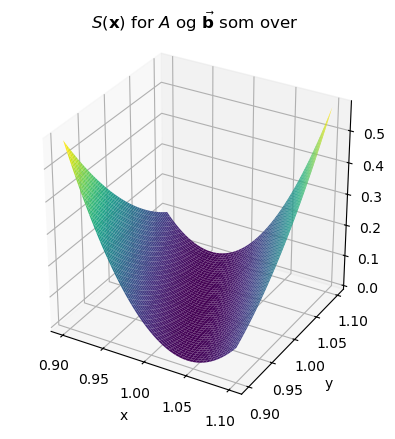

In [3]:
# @title Plotter
# Define the function
def S_fra_A_og_y(A, y):
    ATA = A.T@A
    ATy = A.T@y
    yy = np.sum(y*y)
    def f(x):
        z = np.vstack((x[0].reshape(1, x[0].size), x[1].reshape(1, x[1].size)))
        r1 = np.sum(z * (ATA @ z), axis=0)
        r2 = -2 * np.sum(z * ATy, axis=0)
        r3 = yy
        return 2*(r1 + r2 + r3).reshape(x[0].shape)
    return f

# Create a grid of x and y values
x1 = np.linspace(0.9, 1.1, 300)
x2 = np.linspace(0.9, 1.1, 300)
x = np.meshgrid(x1, x2)

# Compute the function values
S = S_fra_A_og_y(A, y)
x3 = S(x)

# # Mask values outside the unit disc
# mask = x**2 + y**2 > 1  # Create a boolean mask for points outside the unit disc
# z[mask] = np.nan  # Set values outside the unit disc to NaN (they won't be plotted)
# x3[x3>.01]=np.nan

# Create a 3D plotc
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(x[0], x[1], x3, cmap='viridis', edgecolor='none')
plt.title(r'$S(\mathbf{x})$ for $A$ og $\vec{\mathbf{b}}$ som over')

# Set labels
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

# Set the aspect ratio to be equal
ax.set_box_aspect([1, 1, 1])

For å se hva som skjer når $S(x)$ er nær null tar vi logaritmen. Vi må passe litt på med ikke å regne ut logaritmen til null.

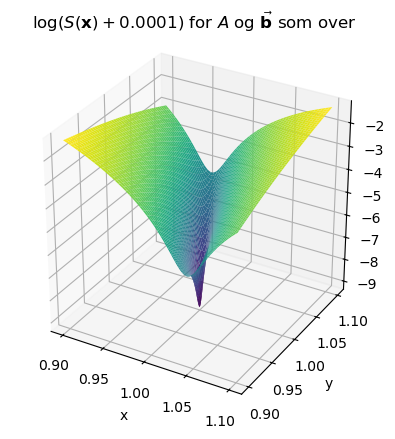

In [4]:
# @title Plotter
# Define the function
def S_fra_A_og_y(A, y):
    ATA = A.T@A
    ATy = A.T@y
    yy = np.sum(y*y)
    def f(x):
        z = np.vstack((x[0].reshape(1, x[0].size), x[1].reshape(1, x[1].size)))
        r1 = np.sum(z * (ATA @ z), axis=0)
        r2 = -2 * np.sum(z * ATy, axis=0)
        r3 = yy
        return (r1 + r2 + r3).reshape(x[0].shape)
    return f

# Create a grid of x and y values
x1 = np.linspace(0.9, 1.1, 300)
x2 = np.linspace(0.9, 1.1, 300)
x = np.meshgrid(x1, x2)

# Compute the function values
S = S_fra_A_og_y(A, y)
x3 = S(x)

# # Mask values outside the unit disc
# mask = x**2 + y**2 > 1  # Create a boolean mask for points outside the unit disc
# z[mask] = np.nan  # Set values outside the unit disc to NaN (they won't be plotted)
# x3[x3>.01]=np.nan

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(x[0], x[1], np.log(x3 + 0.0001), cmap='viridis', edgecolor='none')
plt.title(r'$\log(S(\mathbf{x}) + 0.0001)$ for $A$ og $\vec{\mathbf{b}}$ som over')
# Set labels
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

# Set the aspect ratio to be equal
ax.set_box_aspect([1, 1, 1])